In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#TRABAJO SUMATIVA SEMANA 7
#1.-IMPORTAR LIBRERIAS
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [ ]:
#2.-Definir semillas para su reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
#3.- Cargar el conjunto de datos, digitos escritos a mano de 0-9
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Los datos de entrenamiento y prueba se cargan como imágenes en escala de grises de 28x28 píxeles

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


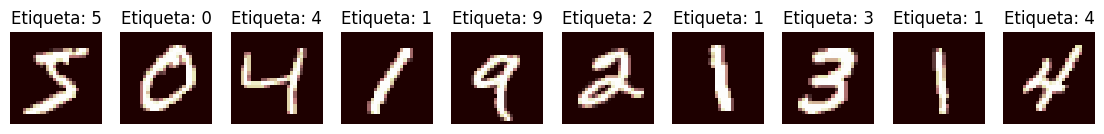

In [ ]:
#4.- Visualización de las imagenes
def mostrar_imagenes(X, y, num_imagenes=10):
    plt.figure(figsize=(14, 2))  # Tamaño de la figura
    for i in range(num_imagenes):
        plt.subplot(1, num_imagenes, i + 1)  # Crear subtrama
        plt.imshow(X[i], cmap='pink')  # Mostrar la imagen en escala de rosado
        plt.title(f'Etiqueta: {y[i]}')  # Mostrar la etiqueta
        plt.axis('off')  # Ocultar los ejes
    plt.show()

# Mostrar las primeras 10 imágenes del conjunto de entrenamiento
mostrar_imagenes(X_train, y_train, num_imagenes=10)

In [ ]:
#5.- Preprocesar los datos
X_train = X_train.astype('float32') / 255.0  # Escalar los píxeles a un rango de [0, 1] para normalización
X_test = X_test.astype('float32') / 255.0    # Lo mismo para los datos de prueba
y_train = tf.keras.utils.to_categorical(y_train, 10)  # Convertir las etiquetas en formato one-hot encoding para 10 clases
y_test = tf.keras.utils.to_categorical(y_test, 10)    # Lo mismo para las etiquetas de prueba

In [ ]:
#6.- Construcción del modelo RED Neuronal
model_multi = Sequential()  # Inicializa un modelo secuencial
model_multi.add(Flatten(input_shape=(28, 28)))  # Aplana las imágenes de 28x28 a un vector de 784 características
model_multi.add(Dense(300, activation='relu'))  # Primera capa oculta con 32 neuronas y función de activación 'relu'
model_multi.add(Dense(28, activation='relu'))   # Segunda capa oculta con 512 neuronas y función de activación 'relu'
model_multi.add(Dense(10, activation='softmax'))  # Capa de salida con 10 neuronas (una por clase) y activación 'softmax' para clasificación multiclase



In [ ]:
#7.- Compilación del Modelo
model_multi.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
# Utiliza el optimizador Adam con una tasa de aprendizaje de 0.001
# La función de pérdida 'categorical_crossentropy' es adecuada para problemas de clasificación multiclase
# La métrica 'accuracy' mide la precisión del modelo

In [ ]:
#8.- Entrenamiento del modelo
model_multi.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)
# Entrena el modelo durante 10 épocas con un tamaño de lote de 32
# Utiliza un 20% de los datos de entrenamiento para la validación
# 'verbose=1' asegura que el progreso del entrenamiento se muestre en pantalla en cada época

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8755 - loss: 0.4239 - val_accuracy: 0.9632 - val_loss: 0.1286
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9682 - loss: 0.1058 - val_accuracy: 0.9655 - val_loss: 0.1179
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9800 - loss: 0.0666 - val_accuracy: 0.9676 - val_loss: 0.1172
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9865 - loss: 0.0431 - val_accuracy: 0.9707 - val_loss: 0.1106
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9703 - val_loss: 0.1187
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9909 - loss: 0.0264 - val_accuracy: 0.9697 - val_loss: 0.1327
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9932 - loss: 0.0205 - val_accuracy: 0.9749 - val_loss: 0.1052
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9936 - lo

In [ ]:
#9.- Evaluen el modelo
loss_multi, acc_multi = model_multi.evaluate(X_test, y_test)
print(f'Pérdida en el conjunto de prueba (Clasificación Multiclase): {loss_multi}')
print(f'Accuracy en el conjunto de prueba: {acc_multi}')
# Evalúa el modelo con los datos de prueba y muestra la pérdida y accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9771 - loss: 0.3602
Pérdida en el conjunto de prueba (Clasificación Multiclase): 0.2930910289287567
Accuracy en el conjunto de prueba: 0.9807999730110168
